<a href="https://colab.research.google.com/github/VildanaRazumova/VildanaRazumova/blob/main/Learning_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [209]:
sns.set(
    rc={
        'figure.figsize': (10, 5),
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12
    }
) # beauty graph by default

In [147]:
events_data = pd.read_csv('/content/event_data_train.csv')
submissions_data = pd.read_csv('/content/submissions_data_train.csv')

In [148]:
events_data.head()

,step_id,timestamp,action,user_id
0,32815,1434340848,viewed,17632
1,32815,1434340848,passed,17632
2,32815,1434340848,discovered,17632
3,32811,1434340895,discovered,17632
4,32811,1434340895,viewed,17632


In [149]:
events_data.action.nunique()

4

In [150]:
events_data.action.unique()

array(['viewed', 'passed', 'discovered', 'started_attempt'], dtype=object)

In [151]:
events_data['date'] = pd.to_datetime(events_data.timestamp, unit='s')
events_data

,step_id,timestamp,action,user_id,date
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48
1,32815,1434340848,passed,17632,2015-06-15 04:00:48
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35
...,...,...,...,...,...
3480698,33375,1526772685,viewed,11677,2018-05-19 23:31:25
3480699,32815,1526772750,viewed,5198,2018-05-19 23:32:30
3480700,32815,1526772750,discovered,5198,2018-05-19 23:32:30
3480701,32815,1526772750,passed,5198,2018-05-19 23:32:30


In [152]:
events_data.date.max()

Timestamp('2018-05-19 23:33:31')

In [153]:
events_data.date.min()

Timestamp('2015-06-15 04:00:48')

In [154]:
events_data['day'] = events_data.date.dt.date
events_data.head()

,step_id,timestamp,action,user_id,date,day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15


In [155]:
events_data.groupby('day').user_id.nunique().head(5)

,user_id
day,
2015-06-15,705
2015-06-16,526
2015-06-17,440
2015-06-18,411
2015-06-19,377


<Axes: xlabel='day'>

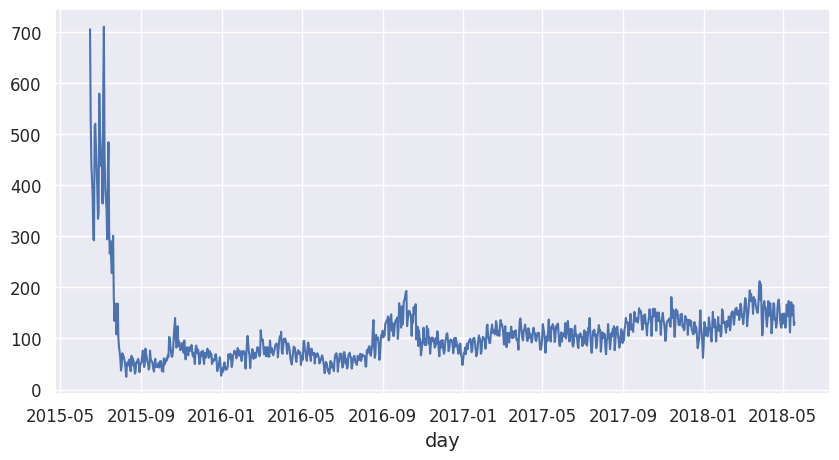

In [156]:
events_data.groupby('day').user_id.nunique().plot()

In [157]:
events_data.groupby('action').user_id.nunique().head(5)

,user_id
action,
discovered,19226
passed,17262
started_attempt,11400
viewed,19227


In [158]:
events_data[events_data.action == 'passed'] \
     .groupby('user_id', as_index=False) \
     .agg({'step_id' : 'count'}) \
     .rename(columns={'step_id': 'passed_steps'}) \
     .head()

,user_id,passed_steps
0,2,9
1,3,87
2,5,11
3,7,1
4,8,84


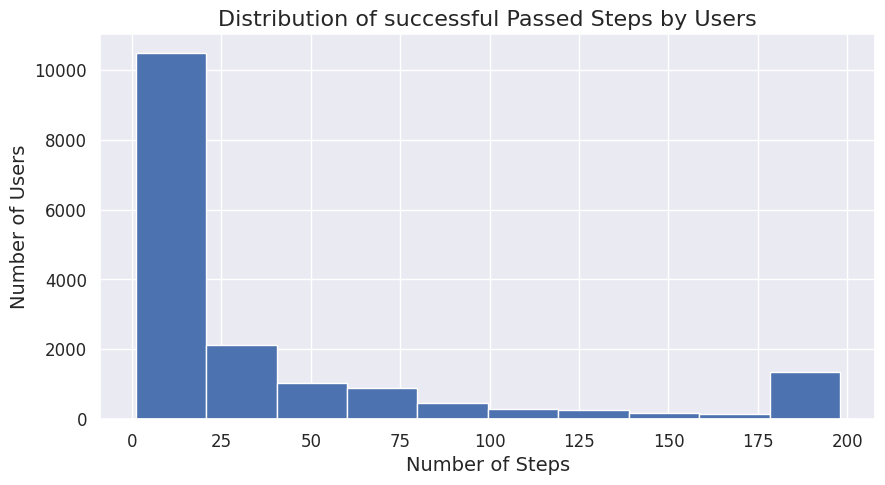

In [159]:
events_data[events_data.action == 'passed'] \
     .groupby('user_id', as_index=False) \
     .agg({'step_id' : 'count'}) \
     .rename(columns={'step_id': 'passed_steps'}).passed_steps.hist()

plt.xlabel("Number of Steps")
plt.ylabel("Number of Users")
plt.title("Distribution of successful Passed Steps by Users")

plt.show() #We lose users who failed or never started.

In [160]:
events_data.head(5)

,step_id,timestamp,action,user_id,date,day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15


In [161]:
events_data.pivot_table(index='user_id',
                        columns='action',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0).reset_index().head()

action,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,10
2,3,91,87,30,192
3,5,11,11,4,12
4,7,1,1,0,1


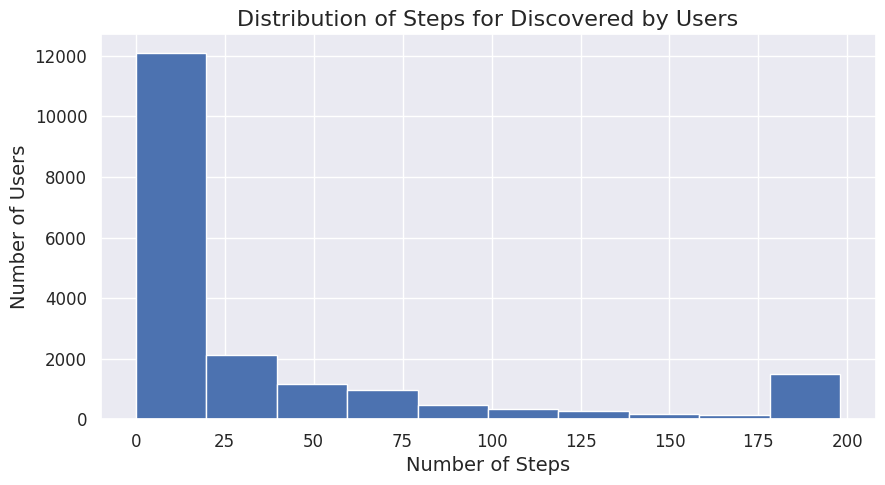

In [162]:
#We don't lose users
events_data.pivot_table(index='user_id',
                        columns='action',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0).reset_index().discovered.hist()


plt.xlabel("Number of Steps")
plt.ylabel("Number of Users")
plt.title("Distribution of Steps for Discovered by Users")

plt.show()

In [163]:
users_events_data = events_data.pivot_table(index='user_id',
                        columns='action',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0).reset_index()

In [186]:
users_events_data.head()

action,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,10
2,3,91,87,30,192
3,5,11,11,4,12
4,7,1,1,0,1


In [165]:
submissions_data.head()

,step_id,timestamp,submission_status,user_id
0,31971,1434349275,correct,15853
1,31972,1434348300,correct,15853
2,31972,1478852149,wrong,15853
3,31972,1478852164,correct,15853
4,31976,1434348123,wrong,15853


In [166]:
submissions_data['date'] = pd.to_datetime(submissions_data.timestamp, unit='s')
submissions_data

,step_id,timestamp,submission_status,user_id,date
0,31971,1434349275,correct,15853,2015-06-15 06:21:15
1,31972,1434348300,correct,15853,2015-06-15 06:05:00
2,31972,1478852149,wrong,15853,2016-11-11 08:15:49
3,31972,1478852164,correct,15853,2016-11-11 08:16:04
4,31976,1434348123,wrong,15853,2015-06-15 06:02:03
...,...,...,...,...,...
509099,120745,1501946959,wrong,2615,2017-08-05 15:29:19
509100,120745,1503059927,correct,13177,2017-08-18 12:38:47
509101,120745,1506348153,wrong,15253,2017-09-25 14:02:33
509102,120745,1523035316,wrong,1424,2018-04-06 17:21:56


In [167]:
submissions_data.date.max()

Timestamp('2018-05-19 23:07:07')

In [168]:
submissions_data.date.min()

Timestamp('2015-06-15 04:02:24')

In [169]:
submissions_data['day'] = submissions_data.date.dt.date
submissions_data.head()

,step_id,timestamp,submission_status,user_id,date,day
0,31971,1434349275,correct,15853,2015-06-15 06:21:15,2015-06-15
1,31972,1434348300,correct,15853,2015-06-15 06:05:00,2015-06-15
2,31972,1478852149,wrong,15853,2016-11-11 08:15:49,2016-11-11
3,31972,1478852164,correct,15853,2016-11-11 08:16:04,2016-11-11
4,31976,1434348123,wrong,15853,2015-06-15 06:02:03,2015-06-15


In [170]:
users_scores = submissions_data.pivot_table(index='user_id',
                        columns='submission_status',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0).reset_index().head()
users_scores

submission_status,user_id,correct,wrong
0,2,2,0
1,3,29,23
2,5,2,2
3,8,9,21
4,14,0,1


In [171]:
gap_data = events_data[['user_id', 'day', 'timestamp']] \
    .drop_duplicates(subset=['user_id', 'day']) \
    .groupby('user_id')['timestamp'].apply(list) \
    .apply(np.diff).values


In [172]:
gap_data = pd.Series(np.concatenate(gap_data, axis=0))

In [173]:
gap_data = gap_data / (24 * 60 * 60)

<Axes: >

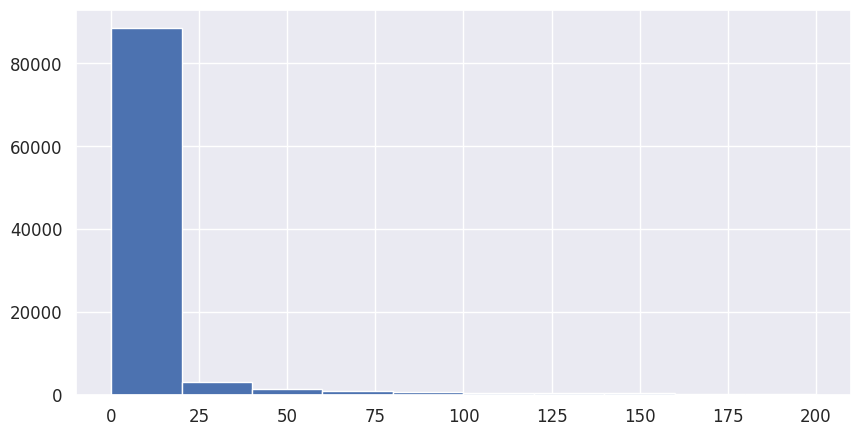

In [174]:
gap_data[gap_data < 200].hist()

In [175]:
gap_data.quantile(0.90)

18.325995370370403

In [176]:
users_scores.groupby('user_id').max('correct')

submission_status,correct,wrong
user_id,,
2,2,0
3,29,23
5,2,2
8,9,21
14,0,1


In [177]:
#the best user with max correct answers
submissions_data[submissions_data['submission_status'] == 'correct'] \
    .groupby('user_id') \
    .agg({'submission_status': 'count'}) \
    .sort_values(by='submission_status', ascending=False)

,submission_status
user_id,
1046,421
5552,186
17135,168
6183,142
8461,135
...,...
6191,1
6184,1
6166,1


In [178]:
events_data.tail()

,step_id,timestamp,action,user_id,date,day
3480698,33375,1526772685,viewed,11677,2018-05-19 23:31:25,2018-05-19
3480699,32815,1526772750,viewed,5198,2018-05-19 23:32:30,2018-05-19
3480700,32815,1526772750,discovered,5198,2018-05-19 23:32:30,2018-05-19
3480701,32815,1526772750,passed,5198,2018-05-19 23:32:30,2018-05-19
3480702,33892,1526772811,viewed,18526,2018-05-19 23:33:31,2018-05-19


In [179]:
#timestamp for threshold, after this time the user is_gone_user
30 * 24 * 60 * 60

2592000

In [180]:
users_data = events_data.groupby('user_id', as_index=False) \
    .agg({'timestamp' : 'max'}).rename(columns={'timestamp' : 'last_timestamp'})

In [181]:
now = 1526772811
drop_out_threshold = 2592000

In [182]:
users_data['is_gone_user'] = (now - users_data.last_timestamp) > drop_out_threshold

In [183]:
users_data.head()

,user_id,last_timestamp,is_gone_user
0,1,1472827464,True
1,2,1519226966,True
2,3,1444581588,True
3,5,1499859939,True
4,7,1521634660,True


In [184]:
users_data = users_data.merge(users_scores, on='user_id', how='outer').fillna(0)

In [188]:
users_data = users_data.merge(users_events_data, on='user_id', how='outer').fillna(0)

In [195]:
users_days = events_data.groupby('user_id').day.nunique().to_frame().reset_index()

In [196]:
users_days = users_data.merge(users_days, on='user_id', how='outer').fillna(0)

In [197]:
users_data.head()

,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,day
0,1,1472827464,True,0.0,0.0,1,0,0,1,1
1,2,1519226966,True,2.0,0.0,9,9,2,10,2
2,3,1444581588,True,29.0,23.0,91,87,30,192,7
3,5,1499859939,True,2.0,2.0,11,11,4,12,2
4,7,1521634660,True,0.0,0.0,1,1,0,1,1


In [198]:
users_data.user_id.nunique()

19234

In [199]:
events_data.user_id.nunique()

19234

In [206]:
users_data['passed_course'] = users_data.passed > 170

In [207]:
users_data.groupby('passed_course').count()

,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,day,passed_corse
passed_course,,,,,,,,,,,
False,17809,17809,17809,17809,17809,17809,17809,17809,17809,17809,17809
True,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425


In [208]:
1425 / 17809 * 100

8.001572238755687